# Tutorial: Milestone 4 - Cross-Modal Dialogue

Audience:
- You've completed Milestone 3 (MISA fusion: shared/private modality representations,
  self-attention over 6 fixed vectors, one utterance classified in isolation).

Prerequisites:
- Run `python src/generate_dialogue_data.py`, `python src/extract_dialogue_embeddings.py`,
  `python src/crossmodal_model.py` (a quick smoke test), and `python src/train_crossmodal.py`
  at least once first -- this notebook imports the model class from `src/crossmodal_model.py`
  rather than redefining it, exactly like Milestone 3's notebook imported `src/misa_model.py`.

Learning goals:
- By the end, you can explain the difference between cross-attention and self-attention,
  what a padding mask is and why this milestone needs one, and why splitting the data by
  EPISODE (not by row) matters here in a way it didn't for any earlier milestone.

**What's new here:** every milestone through M3 classified one utterance in isolation, with
no notion of "what was said before it." This milestone is the first to use dialogue context
(up to 4 preceding utterances) and the first to let one modality's sequence directly attend
into another modality's sequence (cross-attention), rather than attending within a fixed set
of per-utterance representations (M3's self-attention).


## Outline

1. Setup
2. Step 1 - Load the dialogue index (512 rows, 10 episodes)
3. Step 1b - How contiguous is this "dialogue", really? (measured)
4. Step 2 - Split by EPISODE, not by row (context leakage)
5. Step 3 - The cross-modal architecture, in plain language
6. Step 4 - Build the dialogue-window tensors (and the padding mask)
7. Step 5 - Train THREE models: full, no-cross-attention, no-dialogue-context
8. Training curves (all three, side by side)
9. Step 6 - Evaluate all three on the held-out test episodes
10. Confusion matrix
11. Compare against every prior milestone (against each one's trivial baseline)
12. What the no-context ablation actually tells us
13. Look at the mistakes
14. Exercises
15. Pitfalls and extensions

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from crossmodal_model import CrossModalDialogueModel, WINDOW_SIZE  # the reviewed model class -- not redefined here

INDEX_PATH = PROJECT_ROOT / "data" / "dialogue" / "index.csv"
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "dialogue" / "embeddings"

AUDIO_SEQ_LEN = 8
N_FRAMES = 5
print(f"WINDOW_SIZE (context + target) = {WINDOW_SIZE}")
INDEX_PATH


WINDOW_SIZE (context + target) = 5


WindowsPath('C:/Users/dbest/Downloads/multimodal-intent-inference/multimodal-intent-inference/data/dialogue/index.csv')

## Step 1 - Load the dialogue index

Unlike M2/M3's 300-clip *stratified* sample (15 clips per intent class, scattered across 43
episodes, so no two clips were ever near each other in the same episode), this milestone takes
**every annotated clip from 10 episodes** (512 rows), so that each utterance has *some* earlier
utterances from the same episode available to it as context.

Each row already has its up-to-4-preceding-utterance context precomputed as
`context_sample_ids` (semicolon-joined, oldest first, empty for an episode's very first
annotated utterance).

> **A correction worth reading before you go any further.** An earlier version of this notebook
> described these as 10 "complete, contiguous" episodes providing "real, temporally-ordered
> dialogue." **That was factually wrong**, and the next section measures exactly how wrong.
> MIntRec annotates only a thin slice of each episode, so "the 4 utterances before this one"
> here does *not* mean "the previous four things anyone said." The correction matters enough
> that this milestone now trains a third model with no context at all, to measure what the
> context is actually worth.

In [2]:
df = pd.read_csv(INDEX_PATH)
df["context_sample_ids"] = df["context_sample_ids"].fillna("")
n_episodes = df.groupby(["season", "episode"]).ngroups
print(f"Loaded {len(df)} rows across {n_episodes} episodes")
df[["sample_id", "target_text", "target_intent", "season", "episode", "context_sample_ids"]].head()


Loaded 512 rows across 10 episodes


,sample_id,target_text,target_intent,season,episode,context_sample_ids
0,S04_E01_29,thanks for the company.,Thank,S04,E01,
1,S04_E01_31,thank you for always tipping 20 bucks,Thank,S04,E01,S04_E01_29
2,S04_E01_42,or you guys can just use your phones for all t...,Inform,S04,E01,S04_E01_29;S04_E01_31
3,S04_E01_77,"these are all excellent ideas, thank you.",Praise,S04,E01,S04_E01_29;S04_E01_31;S04_E01_42
4,S04_E01_87,"thanks for checking in, though!",Thank,S04,E01,S04_E01_29;S04_E01_31;S04_E01_42;S04_E01_77


## Step 1b - How contiguous is this "dialogue", really?

Before trusting the phrase "dialogue context," measure it. Every row carries a `clip` number:
the position of that clip within its episode. If MIntRec had annotated every clip, consecutive
annotated rows in an episode would have clip numbers differing by 1, and a 4-utterance context
window really would be the previous four conversational turns.

Two things to check, both straight from `data/dialogue/index.csv`:

1. **Coverage** - how many of the clip numbers an episode spans actually have an annotated row?
2. **Gap** - how many clip numbers separate an utterance from the annotated utterance before it?

In [3]:
print(f"{'episode':>9} {'rows':>5} {'clip range':>12} {'coverage':>9} {'median gap':>11}")
gaps_all = []
for (season, episode), group in df.groupby(["season", "episode"]):
    clips = sorted(group["clip"].tolist())
    span = clips[-1] - clips[0] + 1          # clip numbers this episode's annotations stretch over
    gaps = np.diff(clips)                     # distance to the previous ANNOTATED clip
    gaps_all.extend(gaps.tolist())
    print(f"{season + '/' + episode:>9} {len(clips):>5} {f'{clips[0]}-{clips[-1]}':>12} "
          f"{len(clips) / span:>8.1%} {np.median(gaps):>11.1f}")

gaps_all = np.array(gaps_all)
print(f"\nPooled over all 10 episodes ({len(gaps_all)} context->target pairs):")
print(f"  median gap = {np.median(gaps_all):.0f} clip numbers   mean = {gaps_all.mean():.1f}   max = {gaps_all.max()}")
print(f"  literally consecutive clips (gap == 1): {(gaps_all == 1).sum()}/{len(gaps_all)} "
      f"({(gaps_all == 1).mean():.1%})")

# Read one real 4-context window from a held-out test episode, start to finish.
by_id = df.set_index("sample_id")
example = [r for r in df.itertuples(index=False)
           if (r.season, r.episode) == ("S05", "E20") and len(r.context_sample_ids.split(";")) == 4][10]
print("\nOne real dialogue window from a test episode, read top to bottom:")
for sid in example.context_sample_ids.split(";"):
    rec = by_id.loc[sid]
    print(f"  ctx clip {rec['clip']:>4} [{rec['target_intent']:>10}]  {rec['target_text'][:58]}")
print(f"  TGT clip {example.clip:>4} [{example.target_intent:>10}]  {example.target_text[:58]}")

  episode  rows   clip range  coverage  median gap
  S04/E01    42       29-511     8.7%         8.0
  S04/E04    44       23-515     8.9%         7.0
  S04/E16    57        8-568    10.2%         7.0
  S05/E18    60        4-585    10.3%         6.0
  S05/E19    61        3-570    10.7%         6.0
  S05/E20    53        8-547     9.8%         6.5
  S06/E01    54       20-564     9.9%         8.0
  S06/E02    40        1-526     7.6%        11.0
  S06/E03    51        4-622     8.2%         6.0
  S06/E04    50        1-604     8.3%         4.0

Pooled over all 10 episodes (502 context->target pairs):
  median gap = 7 clip numbers   mean = 11.0   max = 118
  literally consecutive clips (gap == 1): 60/502 (12.0%)

One real dialogue window from a test episode, read top to bottom:
  ctx clip  110 [   Comfort]  okay, dina, relax. it's just a surprise date.
  ctx clip  121 [     Taunt]  oh, i love it. you should let it all down.
  ctx clip  127 [ Apologise]  i'm sorry, cheyenne. gecko lady'

**What that shows.** Coverage is roughly 8-10% of the clip numbers each episode spans. The
median gap between an utterance and the annotated utterance before it is several clip numbers,
and only about one pair in eight is literally consecutive. The printed window is not a
conversation - it is a handful of sparsely-sampled moments from the same ~20-minute episode,
frequently from different scenes with different people talking.

So the honest description of this milestone's "dialogue window" is: **the 4 most recently
*annotated* utterances in the same episode**. That is still structured neighbour information
(same episode, correct relative order), and it is still worth testing - but it is not what
"dialogue context" normally means, and we should expect less of it than the phrase suggests.

Rather than argue about it, Step 5 trains a third model that is given **no context at all** and
compares. That turns an assumption into a measurement.

## Step 2 - Split by EPISODE, not by row

**This is worth its own section, because it's a real and easy-to-get-wrong methodological
point.** Every single prior milestone in this project (M0 through M3) split its data with
`sklearn.model_selection.train_test_split` at the *row* level: shuffle every example, carve
off some percentage for train/val/test. That was fine when every row was independent -- one
utterance, classified with no reference to any other row.

That assumption breaks here. Each row's features now include up to 4 *other* rows' audio,
video, and text (its dialogue context). If a plain row-level split were used, it would be
entirely possible for utterance 50's context (utterances 46-49) to land in the **training**
split while utterance 50 itself landed in the **test** split. The model would then effectively
be evaluated on a test example that it partially saw during training -- test performance would
look better than the model actually deserves, without the model having learned anything more
general. This is called **context leakage** (a special case of the more general "data
leakage"), and it is a genuine bug, not a theoretical concern: the whole point of a held-out
test set is that nothing about it, directly or indirectly, was visible during training.

The fix: split at the **episode** level instead. All 512 rows from a given episode go
entirely into train, entirely into val, or entirely into test -- never split across two of
them. Since every row's context always comes from its own episode (context never crosses
episode boundaries -- an episode's first few utterances just have less context, see Step 4),
an episode-level split guarantees no context lookup can ever cross a split boundary.

7 episodes go to train, 1 to val, 2 to test (seeded, not stratified -- stratifying only 10
groups by which of 20 classes they contain isn't practically meaningful with groups this
small; a plain seeded selection is used and stated as such, not dressed up as more rigorous
than it is).


In [4]:
# Episodes assigned to each split -- by EPISODE, not by utterance, so a
# target utterance's context never crosses into a different split than the
# target itself. Same assignment as src/train_crossmodal.py.
TRAIN_EPISODES = [
    ("S04", "E16"), ("S04", "E04"), ("S04", "E01"), ("S05", "E19"),
    ("S05", "E18"), ("S06", "E03"), ("S06", "E04"),
]
VAL_EPISODES = [("S06", "E02")]
TEST_EPISODES = [("S05", "E20"), ("S06", "E01")]


def episode_in(row, episode_set):
    return (row["season"], row["episode"]) in episode_set


train = df[df.apply(lambda r: episode_in(r, TRAIN_EPISODES), axis=1)].reset_index(drop=True)
val = df[df.apply(lambda r: episode_in(r, VAL_EPISODES), axis=1)].reset_index(drop=True)
test = df[df.apply(lambda r: episode_in(r, TEST_EPISODES), axis=1)].reset_index(drop=True)

print(f"train: {len(train)} samples across {len(TRAIN_EPISODES)} episodes")
print(f"val:   {len(val)} samples across {len(VAL_EPISODES)} episode")
print(f"test:  {len(test)} samples across {len(TEST_EPISODES)} episodes")


train: 365 samples across 7 episodes
val:   40 samples across 1 episode
test:  107 samples across 2 episodes


## Step 3 - The cross-modal architecture, in plain language

**Cross-attention vs. self-attention.** M3's MISA took a single utterance, encoded it into 6
fixed vectors (3 "shared" + 3 "private", one per modality), and ran **self-attention** over
those 6 vectors -- each of the 6 could look at the other 5 and itself, refining its own
representation. Every input to that attention step was a representation of the *same*
utterance.

This milestone does something different: **cross-attention**, where one modality's sequence
directly attends *into* another modality's sequence. Concretely -- M3 let 6 fixed
representations attend to each other; M4 lets one modality's sequence (audio's 8 timesteps,
video's 5 frames) directly attend into another modality's sequence (text), rather than
attending within a fixed set of per-utterance representations. Audio and video aren't
squashed into single vectors first and then mixed in with text symmetrically -- instead, text
acts as a **query** ("what should I look for"), and audio/video act as **key/value** pairs
("what's available to match against" / "what do I actually retrieve"). The result is a text
representation that has been *enriched* by whichever audio timesteps and video frames were
most relevant to it, rather than an unweighted average of all of them.

**Dialogue context.** On top of that, this milestone gives the model up to 4 utterances of
context before the target. Each of the 5 window positions (4 context + 1 target) goes through
the same audio-to-text / video-to-text cross-attention step, producing one enriched vector per
utterance. Those 5 vectors are then stacked into a short sequence and run through one more
**self-attention** layer (`dialogue_self_attn` below) -- so the target utterance's final
representation can be influenced by the context utterances around it -- before the last
(target) position is classified. So this milestone actually uses *both* mechanisms: cross-
attention (audio/video into text, per utterance) and self-attention (across the 5-position
dialogue window) -- just not self-attention over a fixed per-modality decomposition the way M3
did.

**What is a padding mask, and why does this milestone need one?** Not every utterance has a
full 4-utterance history -- an episode's first utterance has zero real predecessors, its
second utterance has one, and so on. Rather than dropping those rows (losing training data) or
pretending they have context they don't, `build_window_tensors` (Step 4) fills the missing
context positions with zeros and marks them in a **padding mask**: a `(batch, WINDOW_SIZE)`
boolean array where `True` means "this position is a placeholder, not real data." The
dialogue-window self-attention layer is told to ignore `True` positions entirely, so an
episode's early utterances aren't penalized for having a shorter history -- the model attends
only over whatever real context actually exists.


In [5]:
# Peek at the model's structure and size (text_dim is a placeholder just to inspect shape;
# the real text_dim comes from the TF-IDF vectorizer in Step 4).
model_preview = CrossModalDialogueModel(text_dim=1400, hidden_dim=128, num_classes=20)
print(model_preview)


def count_effective_params(model):
    """Parameters that actually receive a gradient.

    In the no-cross-attention ablation, `audio_to_text_attn` and `video_to_text_attn` are still
    CONSTRUCTED (so `sum(p.numel() ...)` counts them) but are never called in `forward`, so they
    get no gradient and never change. Counting them would overstate that model's capacity, which
    is why the two variants are NOT equal-capacity even though they declare the same number."""
    declared = sum(p.numel() for p in model.parameters())
    if model.use_cross_attention:
        return declared, declared
    inert = sum(p.numel() for name, p in model.named_parameters()
                if name.startswith("audio_to_text_attn") or name.startswith("video_to_text_attn"))
    return declared, declared - inert


ablation_preview = CrossModalDialogueModel(text_dim=1400, hidden_dim=128, num_classes=20,
                                           use_cross_attention=False)
print()
for name, m in [("full model", model_preview), ("no-cross-attention ablation", ablation_preview)]:
    declared, effective = count_effective_params(m)
    print(f"{name:<28} declared {declared:>9,}   effective (gets gradient) {effective:>9,}")
print("\nThe two DECLARED counts are equal; the EFFECTIVE ones are not. That gap (132,096")
print("inert cross-attention parameters) is why calling these two models 'identical capacity'")
print("would be wrong. Absolute numbers here use the placeholder text_dim=1400; the real ones")
print("(766,484 vs. 634,388, a 1.21x ratio) print during training in Step 5.")

CrossModalDialogueModel(
  (text_proj): Linear(in_features=1400, out_features=128, bias=True)
  (audio_proj): Linear(in_features=768, out_features=128, bias=True)
  (video_proj): Linear(in_features=512, out_features=128, bias=True)
  (audio_to_text_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (video_to_text_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (dialogue_self_attn): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,),

## Step 4 - Build the dialogue-window tensors

For every row, build a `(WINDOW_SIZE, ...)` tensor of text/audio/video features -- one slot
per window position -- plus the padding mask described above. Context positions are
**left-padded**: the earliest real context goes as far left as fits, and the last position
(`WINDOW_SIZE - 1`) is always the target utterance, never padding. Context utterances always
come from the same episode as their target (and episodes are entirely within one split), so
every context lookup resolves inside the same dataframe -- no cross-split lookup is possible.


In [6]:
def load_npz(sample_id):
    data = np.load(EMBEDDINGS_DIR / f"{sample_id}.npz")
    return data["audio"], data["video"]  # (8, 768), (5, 512)


def build_window_tensors(frame_df, tfidf, fit):
    if fit:
        text_matrix = tfidf.fit_transform(frame_df["target_text"]).toarray().astype(np.float32)
    else:
        text_matrix = tfidf.transform(frame_df["target_text"]).toarray().astype(np.float32)
    text_dim = text_matrix.shape[1]
    text_by_id = {sid: text_matrix[i] for i, sid in enumerate(frame_df["sample_id"])}

    n = len(frame_df)
    text_window = np.zeros((n, WINDOW_SIZE, text_dim), dtype=np.float32)
    audio_window = np.zeros((n, WINDOW_SIZE, AUDIO_SEQ_LEN, 768), dtype=np.float32)
    video_window = np.zeros((n, WINDOW_SIZE, N_FRAMES, 512), dtype=np.float32)
    padding_mask = np.ones((n, WINDOW_SIZE), dtype=bool)  # start all-padding, fill in real positions

    for row_idx, row in enumerate(frame_df.itertuples(index=False)):
        context_ids = [c for c in row.context_sample_ids.split(";") if c]
        n_context = len(context_ids)
        start = WINDOW_SIZE - 1 - n_context  # left-pad: earliest real context goes here

        for j, sid in enumerate(context_ids):
            pos = start + j
            padding_mask[row_idx, pos] = False
            a, v = load_npz(sid)
            audio_window[row_idx, pos] = a
            video_window[row_idx, pos] = v
            text_window[row_idx, pos] = text_by_id[sid]

        padding_mask[row_idx, WINDOW_SIZE - 1] = False
        a, v = load_npz(row.sample_id)
        audio_window[row_idx, WINDOW_SIZE - 1] = a
        video_window[row_idx, WINDOW_SIZE - 1] = v
        text_window[row_idx, WINDOW_SIZE - 1] = text_by_id[row.sample_id]

    return text_window, audio_window, video_window, padding_mask, text_dim


def to_tensors(text, audio, video, mask, labels, label2id):
    return (
        torch.from_numpy(text), torch.from_numpy(audio), torch.from_numpy(video),
        torch.from_numpy(mask),
        torch.tensor([label2id[l] for l in labels], dtype=torch.long),
    )


tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
text_train, audio_train, video_train, mask_train, text_dim = build_window_tensors(train, tfidf, fit=True)
text_val, audio_val, video_val, mask_val, _ = build_window_tensors(val, tfidf, fit=False)
text_test, audio_test, video_test, mask_test, _ = build_window_tensors(test, tfidf, fit=False)
print(f"Text feature dim: {text_dim}")

labels_sorted = sorted(df["target_intent"].unique())
label2id = {name: i for i, name in enumerate(labels_sorted)}
id2label = {i: name for name, i in label2id.items()}

train_tensors = to_tensors(text_train, audio_train, video_train, mask_train, train["target_intent"].tolist(), label2id)
val_tensors = to_tensors(text_val, audio_val, video_val, mask_val, val["target_intent"].tolist(), label2id)
test_tensors = to_tensors(text_test, audio_test, video_test, mask_test, test["target_intent"].tolist(), label2id)
print(f"Window shape per split: text {text_train.shape}, audio {audio_train.shape}, video {video_train.shape}, mask {mask_train.shape}")


Text feature dim: 2618
Window shape per split: text (365, 5, 2618), audio (365, 5, 8, 768), video (365, 5, 5, 512), mask (365, 5)


## Step 5 - Train THREE models: full, no-cross-attention, no-dialogue-context

This milestone changed **two** things at once relative to M3: cross-modal attention *and*
dialogue context. If only the full model were trained, any accuracy number would be unattributable
- exactly the mistake M3's final review caught, where most of M2->M3's gain turned out to come
from simply having a trainable neural network rather than from MISA's shared/private split.

So three models are trained here, on the identical data, split, batch size, learning rate, and
seed, differing only in the mechanism under test:

| variant | cross-attention | dialogue context | what it isolates |
|---|---|---|---|
| **full** | yes | yes | the whole milestone |
| **ablation A** (`use_cross_attention=False`) | no (mean-pool instead) | yes | what cross-attention adds |
| **ablation B** (`force_mask_context=True`) | yes | **no** | what dialogue context adds |

**Ablation B costs zero model code.** The model already accepts a `padding_mask` marking which
window positions to ignore. Forcing every context position to "padding" (an OR with the normal
mask) leaves only the target position visible, so `dialogue_self_attn` attends over the target
alone. Crucially this is applied to **training and evaluation alike** - a model trained with
context but tested without it would be an unfair train/test mismatch, and would tell us about
distribution shift rather than about context.

**A word on "same capacity", because an earlier version of this notebook got it wrong.** The full
model and ablation A declare the same parameter count, but they do **not** have the same capacity:
in ablation A the two cross-attention modules are constructed and never called, so they receive no
gradient and are inert. Effective trainable parameters are 766,484 (full) vs. 634,388 (ablation A)
- a 1.21x ratio. The variants are identical *everywhere except the mechanism under test*, which is
what an ablation actually needs; they are not equal-capacity, and this notebook no longer claims
they are.

Each variant is run over **3 seeds**. A 107-row test set spread over 20 classes is small enough
that a single seed's gap can easily be noise, and it would be dishonest to report one seed as if
it settled anything.

In [7]:
import copy

HIDDEN_DIM, BATCH_SIZE, MAX_EPOCHS, PATIENCE, LEARNING_RATE = 128, 16, 100, 15, 1e-3
NUM_CLASSES = 20
SEEDS = (0, 1, 2)                        # seed 0 is the headline run; the rest check it isn't a fluke
ALL_LABEL_IDS = list(range(NUM_CLASSES))  # fixed macro-F1 denominator -- see note below


def mask_all_context(tensors):
    """Return a copy of a (text, audio, video, mask, labels) tuple with EVERY dialogue-context
    position forced to 'padding' -- i.e. the normal padding mask OR'd with 'mask all context'.
    Only the target position (the last one) stays visible.

    This reuses the model's existing `padding_mask` argument, so ablation B needs no model code
    changes at all: `dialogue_self_attn` simply ignores every context position."""
    text, audio, video, mask, labels = tensors
    masked = mask.clone()
    masked[:, :WINDOW_SIZE - 1] = True    # every context position -> ignore
    masked[:, WINDOW_SIZE - 1] = False    # the target position is never padding
    return text, audio, video, masked, labels


def run_epoch(model, optimizer, text, audio, video, mask, labels, batch_size, train_mode):
    model.train(train_mode)
    n = text.shape[0]
    indices = torch.randperm(n) if train_mode else torch.arange(n)
    total_loss = 0.0
    all_preds, all_labels = [], []
    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]
        bt, ba, bv, bm, bl = text[batch_idx], audio[batch_idx], video[batch_idx], mask[batch_idx], labels[batch_idx]
        if train_mode:
            optimizer.zero_grad()
            logits = model(bt, ba, bv, padding_mask=bm)
            loss = torch.nn.functional.cross_entropy(logits, bl)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                logits = model(bt, ba, bv, padding_mask=bm)
                loss = torch.nn.functional.cross_entropy(logits, bl)
        total_loss += loss.item() * len(batch_idx)
        all_preds.extend(logits.argmax(dim=1).tolist())
        all_labels.extend(bl.tolist())
    avg_loss = total_loss / n
    # `labels=` is explicit on purpose. Without it, macro-F1's denominator is however many
    # classes happen to appear in this run's truth/predictions, which drifts from run to run and
    # makes the number not comparable. Pinning it to all 20 intents keeps the metric stable.
    macro_f1 = f1_score(all_labels, all_preds, labels=ALL_LABEL_IDS, average="macro", zero_division=0)
    return avg_loss, macro_f1


def train_model(use_cross_attention, force_mask_context, label, seed=0, verbose=True):
    if verbose:
        print("=" * 70)
        print(f"TRAIN: {label}  (seed {seed})")
        print("=" * 70)
    tr, va = train_tensors, val_tensors
    if force_mask_context:
        tr, va = mask_all_context(tr), mask_all_context(va)
        if verbose:
            print("force_mask_context=True: every context position is masked for training AND")
            print("validation -- this model only ever sees the target utterance.")

    torch.manual_seed(seed)
    model = CrossModalDialogueModel(text_dim=text_dim, hidden_dim=HIDDEN_DIM,
                                    num_classes=NUM_CLASSES, use_cross_attention=use_cross_attention)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1, best_state, epochs_without_improvement = -1.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_f1 = run_epoch(model, optimizer, *tr, BATCH_SIZE, True)
        val_loss, val_f1 = run_epoch(model, optimizer, *va, BATCH_SIZE, False)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1); history["val_f1"].append(val_f1)

        improved = val_f1 > best_val_f1
        if improved:
            best_val_f1, best_state, epochs_without_improvement = val_f1, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_without_improvement += 1
        if verbose and (epoch <= 5 or epoch % 10 == 0 or improved):
            marker = " *" if improved else ""
            print(f"epoch {epoch:3d}  train_loss={train_loss:.4f} train_f1={train_f1:.3f}  "
                  f"val_loss={val_loss:.4f} val_f1={val_f1:.3f}{marker}")
        if epochs_without_improvement >= PATIENCE:
            if verbose:
                print(f"\nEarly stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).")
            break
    else:
        if verbose:
            print(f"\nReached max epochs ({MAX_EPOCHS}) without early stopping.")

    model.load_state_dict(best_state)
    if verbose:
        declared, effective = count_effective_params(model)
        print(f"Restored best checkpoint (val macro-F1={best_val_f1:.3f}).")
        print(f"Parameters: {declared:,} declared, {effective:,} effective (receiving gradient).\n")
    return model, history, best_val_f1


def evaluate(model, label, force_mask_context=False, verbose=True):
    te = mask_all_context(test_tensors) if force_mask_context else test_tensors
    text_t, audio_t, video_t, mask_t, labels_t = te
    model.eval()
    with torch.no_grad():
        logits = model(text_t, audio_t, video_t, padding_mask=mask_t)
    preds = [id2label[p] for p in logits.argmax(dim=1).tolist()]
    truth = [id2label[l] for l in labels_t.tolist()]
    acc = accuracy_score(truth, preds)
    # Explicit `labels=` again: macro-F1 over all 20 intents, not just the ones predicted here.
    macro_f1 = f1_score(truth, preds, labels=labels_sorted, average="macro", zero_division=0)
    if verbose:
        print(f"EVALUATE: {label}\n  Accuracy : {acc:.3f}\n  Macro-F1 : {macro_f1:.3f}\n")
    return acc, macro_f1, truth, preds

In [8]:
VARIANTS = [
    ("full", dict(use_cross_attention=True, force_mask_context=False),
     "full cross-modal + dialogue context"),
    ("no_cross_attn", dict(use_cross_attention=False, force_mask_context=False),
     "ablation A: no cross-attention (mean-pool instead)"),
    ("no_context", dict(use_cross_attention=True, force_mask_context=True),
     "ablation B: no dialogue context (all context masked)"),
]

results = {key: {"acc": [], "f1": [], "val_f1": []} for key, _, _ in VARIANTS}
seed0 = {}
for seed in SEEDS:
    verbose = seed == SEEDS[0]
    if not verbose:
        print(f"--- extra seed {seed} (quiet) ---")
    for key, kwargs, label in VARIANTS:
        model, history, best_val_f1 = train_model(label=label, seed=seed, verbose=verbose, **kwargs)
        acc, f1, truth_, preds_ = evaluate(model, label, kwargs["force_mask_context"], verbose=verbose)
        results[key]["acc"].append(acc)
        results[key]["f1"].append(f1)
        results[key]["val_f1"].append(best_val_f1)
        if verbose:
            seed0[key] = {"model": model, "history": history, "acc": acc, "f1": f1,
                          "preds": preds_, "val_f1": best_val_f1}
            truth = truth_
        else:
            print(f"  seed {seed}  {label:<50} acc={acc:.3f} macro-F1={f1:.3f}")

# Convenient seed-0 aliases used by the cells below.
full_model, full_history = seed0["full"]["model"], seed0["full"]["history"]
ablation_model, ablation_history = seed0["no_cross_attn"]["model"], seed0["no_cross_attn"]["history"]
nocontext_model, nocontext_history = seed0["no_context"]["model"], seed0["no_context"]["history"]
full_acc, full_f1, full_preds = seed0["full"]["acc"], seed0["full"]["f1"], seed0["full"]["preds"]
ablation_acc, ablation_f1 = seed0["no_cross_attn"]["acc"], seed0["no_cross_attn"]["f1"]
nocontext_acc, nocontext_f1 = seed0["no_context"]["acc"], seed0["no_context"]["f1"]

TRAIN: full cross-modal + dialogue context  (seed 0)


C:\Users\dbest\anaconda3\envs\mmi\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


epoch   1  train_loss=2.9358 train_f1=0.032  val_loss=2.9400 val_f1=0.007 *


epoch   2  train_loss=2.7884 train_f1=0.027  val_loss=2.9818 val_f1=0.007


epoch   3  train_loss=2.8025 train_f1=0.030  val_loss=2.8979 val_f1=0.009 *


...

  seed 1  ablation A: no cross-attention (mean-pool instead) acc=0.196 macro-F1=0.133


  seed 1  ablation B: no dialogue context (all context masked) acc=0.224 macro-F1=0.125
--- extra seed 2 (quiet) ---


  seed 2  full cross-modal + dialogue context                acc=0.318 macro-F1=0.168


  seed 2  ablation A: no cross-attention (mean-pool instead) acc=0.168 macro-F1=0.063


  seed 2  ablation B: no dialogue context (all context masked) acc=0.299 macro-F1=0.194


## Training curves (all three, side by side)

M3's notebook had this project's first training-curve plot - one model, one pair of axes. This
extends it to three models at once (seed 0): solid blue is the full model, dashed orange is
ablation A (no cross-attention), dotted green is ablation B (no dialogue context), so you can see
directly whether one overfits faster, plateaus higher, or is noisier than the others.

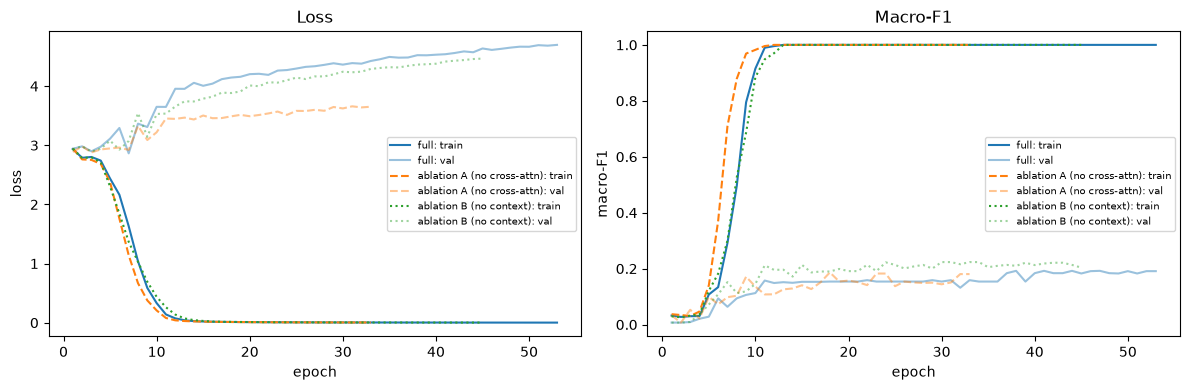

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
series = [
    ("full", full_history, "tab:blue", "-"),
    ("ablation A (no cross-attn)", ablation_history, "tab:orange", "--"),
    ("ablation B (no context)", nocontext_history, "tab:green", ":"),
]

for name, hist, color, style in series:
    epochs = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(epochs, hist["train_loss"], color=color, linestyle=style, label=f"{name}: train")
    axes[0].plot(epochs, hist["val_loss"], color=color, linestyle=style, alpha=0.45, label=f"{name}: val")
    axes[1].plot(epochs, hist["train_f1"], color=color, linestyle=style, label=f"{name}: train")
    axes[1].plot(epochs, hist["val_f1"], color=color, linestyle=style, alpha=0.45, label=f"{name}: val")

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss"); axes[0].legend(fontsize=7)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro-F1"); axes[1].set_title("Macro-F1"); axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

**Reading the curves - and being precise about what early stopping does.**

All three models show the same signature: training loss collapses from ~2.94 to ~0.03 and train
macro-F1 hits **1.000 by roughly epoch 10-15**, while validation loss stops following it down and
climbs steadily from about epoch 2 onward. With only 365 training rows spread over 20 classes and
a ~766k-parameter model, all three memorise the training set outright.

An earlier version of this notebook said early stopping "exists precisely to not hand back an
overfit model." That is too generous to it. **Early stopping only chooses *which* checkpoint to
keep - it does nothing to prevent the memorisation from happening.** The model still overfits, on
the same schedule, whether or not early stopping is switched on; all early stopping buys is a
less-overfit snapshot than the final epoch's weights. Treating the *consequence* is not the same
as treating the *cause*.

Directly attacking the cause would mean **stronger regularisation** - dropout in the encoders and
the transformer layer, weight decay in the optimiser, or simply a smaller model (Exercise 3 below
pokes at exactly this by shrinking `HIDDEN_DIM`). None of those are implemented here; they are
noted as the honest next step rather than glossed over.

**And one more caution about the selection signal itself.** The validation set is a *single
40-row episode*. In this run, ablation B (no context) reached the **highest** validation macro-F1
of the three (0.223, vs. 0.192 full and 0.187 for ablation A) while landing the **lowest** test
macro-F1 (0.138, vs. 0.150 and 0.157). Ablation A likewise beat the full model on test macro-F1
(0.157 vs. 0.150) despite a *lower* validation score. In other words, on this data the validation
signal that "restored best checkpoint" relies on does not reliably order the models the way the
test set does. That does not invalidate anything reported below - the test set is still the honest
metric, and it is never used for selection - but "restored best checkpoint" here is a noisy
process, not a precise one. The robust fix is **leave-one-episode-out cross-validation** across
all 10 episodes (10x the effective evaluation data, and every episode gets a turn as validation),
which is deferred to Milestone 5's evaluation work.

## Step 6 - Evaluate all three on the held-out test episodes

All three models are evaluated on the exact same 107-row test split (2 held-out episodes), never
seen during training or for early stopping. Ablation B is evaluated with its context masked too,
matching how it was trained.

The evaluation already ran inside the loop above; this cell just lays the seed-0 numbers out side
by side, next to the number that matters most for reading them: the **trivial majority-class
baseline**, i.e. what you would score by ignoring the input entirely and always predicting the
single most common intent in the test set.

In [10]:
test_counts = test["target_intent"].value_counts()
m4_majority = test_counts.iloc[0] / len(test)
print(f"Test split: {len(test)} rows, {test_counts.size} intents present, "
      f"most common = '{test_counts.index[0]}' ({test_counts.iloc[0]} rows)")
print(f"Trivial majority-class baseline accuracy = {m4_majority:.3f}\n")

print(f"{'variant (seed 0)':<52} {'accuracy':>9} {'macro-F1':>9}")
for key, _, label in VARIANTS:
    print(f"{label:<52} {seed0[key]['acc']:>9.3f} {seed0[key]['f1']:>9.3f}")
print(f"{'--- always predict the majority class ---':<52} {m4_majority:>9.3f} {'n/a':>9}")

print(f"\nAcross all {len(SEEDS)} seeds {SEEDS}:")
print(f"{'variant':<52} {'acc mean+-sd':>16} {'macro-F1 mean+-sd':>20}")
for key, _, label in VARIANTS:
    a, f = np.array(results[key]["acc"]), np.array(results[key]["f1"])
    print(f"{label:<52} {a.mean():>8.3f} +- {a.std():<5.3f} {f.mean():>11.3f} +- {f.std():<5.3f}")

Test split: 107 rows, 19 intents present, most common = 'Inform' (24 rows)
Trivial majority-class baseline accuracy = 0.224

variant (seed 0)                                      accuracy  macro-F1
full cross-modal + dialogue context                      0.290     0.150
ablation A: no cross-attention (mean-pool instead)       0.243     0.157
ablation B: no dialogue context (all context masked)     0.271     0.138
--- always predict the majority class ---                0.224       n/a

Across all 3 seeds (0, 1, 2):
variant                                                  acc mean+-sd    macro-F1 mean+-sd
full cross-modal + dialogue context                     0.290 +- 0.023       0.163 +- 0.009
ablation A: no cross-attention (mean-pool instead)      0.202 +- 0.031       0.118 +- 0.040
ablation B: no dialogue context (all context masked)    0.265 +- 0.031       0.152 +- 0.030


In [11]:
print(classification_report(truth, full_preds, zero_division=0))


              precision    recall  f1-score   support

      Advise       0.10      0.25      0.14         4
       Agree       0.00      0.00      0.00         1
   Apologise       1.00      0.29      0.44        14
     Arrange       0.14      0.25      0.18         4
Ask for help       0.00      0.00      0.00         1
        Care       0.43      0.60      0.50         5
     Comfort       0.00      0.00      0.00         6
    Complain       0.20      0.33      0.25         6
   Criticize       0.33      0.50      0.40         8
      Flaunt       0.00      0.00      0.00         0
       Greet       0.00      0.00      0.00         4
      Inform       0.32      0.50      0.39        24
   Introduce       0.00      0.00      0.00         6
        Joke       0.00      0.00      0.00         2
       Leave       0.00      0.00      0.00         5
      Oppose       0.00      0.00      0.00         1
      Praise       0.17      0.12      0.14         8
     Prevent       0.00    

## Confusion matrix

For the full cross-modal model, on the same 20 real MIntRec intent classes used since M1.


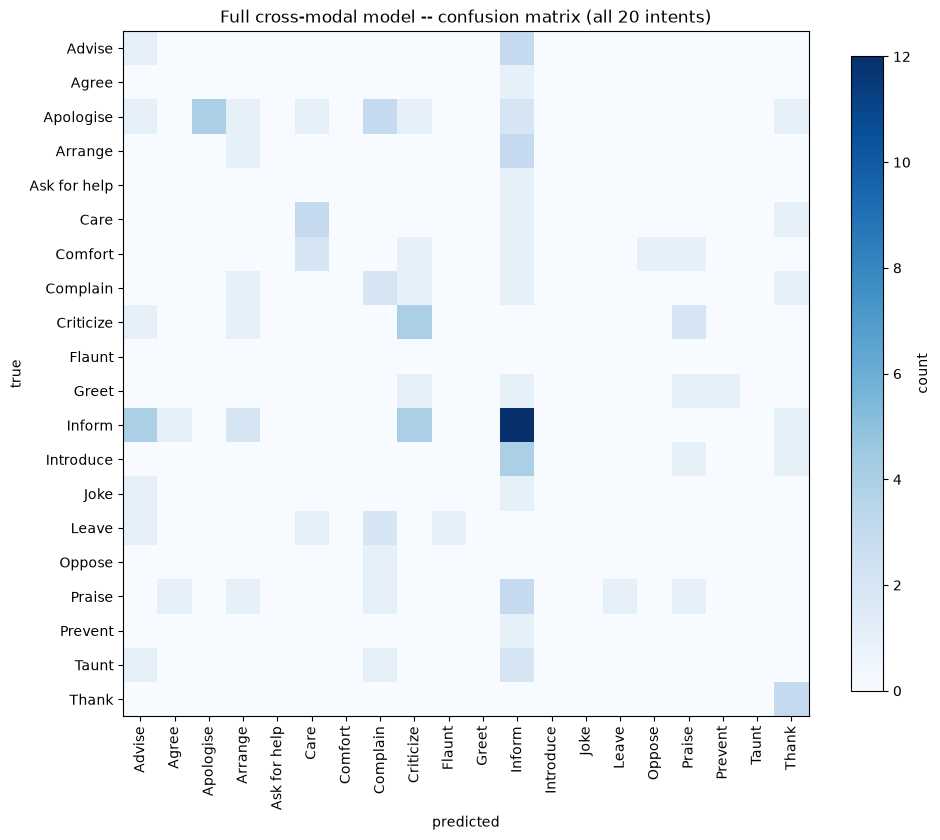

In [12]:
# Use the FULL 20-class label set, not just the classes this run happened to predict --
# otherwise the matrix silently changes shape from run to run. This matches Milestone 3's
# effective convention (its balanced test set always contained all 20 classes).
cm = confusion_matrix(truth, full_preds, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_sorted)), labels_sorted, rotation=90)
ax.set_yticks(range(len(labels_sorted)), labels_sorted)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Full cross-modal model -- confusion matrix (all 20 intents)")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()

## Compare against every prior milestone - against each one's trivial baseline

Same honest caveat `src/train_crossmodal.py` prints at the end of its run: this milestone's
512-clip, 10-episode dataset is **different** from M2/M3's 300-clip stratified sample and
different again from M1's full 2,224-row text-only dataset. These rows are directional
comparisons across different data, **not** a controlled like-for-like experiment. The one
apples-to-apples experiment in this notebook is the three-variant comparison above, where data,
split, and training procedure are identical.

**And there is a second reason raw accuracies must not be compared directly here.** The datasets
have wildly different *trivial* baselines:

- **M2/M3's test set was perfectly balanced** - 60 rows, 20 intents, exactly 3 each - so always
  guessing the most common class scores **0.050**.
- **M4's test set is two real episodes and is badly imbalanced** - `Inform` alone is 24 of 107
  rows - so always guessing the most common class scores **0.224**, more than 4x higher.

A raw accuracy of 0.29 on M4 and 0.33 on M3 look almost equivalent. Measured against what each
dataset gives away for free, they are not remotely equivalent. The table below therefore adds a
baseline column and a "how many times its own baseline" column, which is the honest way to read
it. (M1's baseline is the majority-class share of the full 2,224-row MIntRec label
distribution, 0.129 - approximate, since M1's exact test split isn't reconstructed here.)

In [13]:
M3_BASELINE = 3 / 60      # M3/M2 test set: 60 rows, 20 classes, exactly 3 each (verified)
M1_BASELINE = 0.129       # majority-class share of the full 2,224-row MIntRec labels (approximate)

rows = [
    ("M1: text-only (real MIntRec, full 2,224-row dataset)", 0.508, 0.409, M1_BASELINE),
    ("M2: concatenation fusion (300-clip stratified sample)", 0.117, 0.096, M3_BASELINE),
    ("M3: MISA fusion (same 300-clip sample)", 0.333, 0.295, M3_BASELINE),
]
for key, _, label in VARIANTS:
    rows.append((f"M4: {label} (mean of {len(SEEDS)} seeds)",
                 float(np.mean(results[key]["acc"])), float(np.mean(results[key]["f1"])), m4_majority))
rows.append(("M4: trivial majority-class baseline (predicts 'Inform' always)",
             m4_majority, np.nan, m4_majority))

comparison = pd.DataFrame(rows, columns=["model", "accuracy", "macro_f1", "trivial_baseline_acc"])
comparison["x_own_baseline"] = (comparison["accuracy"] / comparison["trivial_baseline_acc"]).round(2)
comparison = comparison.set_index("model").round(3)
comparison

,accuracy,macro_f1,trivial_baseline_acc,x_own_baseline
model,,,,
"M1: text-only (real MIntRec, full 2,224-row dataset)",0.508,0.409,0.129,3.94
M2: concatenation fusion (300-clip stratified sample),0.117,0.096,0.050,2.34
M3: MISA fusion (same 300-clip sample),0.333,0.295,0.050,6.66
M4: full cross-modal + dialogue context (mean of 3 seeds),0.290,0.163,0.224,1.29
M4: ablation A: no cross-attention (mean-pool instead) (mean of 3 seeds),0.202,0.118,0.224,0.90
M4: ablation B: no dialogue context (all context masked) (mean of 3 seeds),0.265,0.152,0.224,1.18
M4: trivial majority-class baseline (predicts 'Inform' always),0.224,NaN,0.224,1.00


**Interpretation - honest, not overclaimed.**

**1. Cross-attention does appear to help, modestly.** Averaged over 3 seeds on the identical
data and split: the full model reaches accuracy **0.290 +- 0.023** / macro-F1 **0.163 +- 0.009**,
while ablation A (cross-attention replaced with mean-pooling) reaches **0.202 +- 0.031** /
**0.118 +- 0.040**. That is a +0.087 accuracy gap, comfortably larger than either variant's
seed-to-seed spread, and the full model won on accuracy in all 3 seeds. It is a real signal on
this data - though on seed 0 specifically ablation A actually edged the full model on *macro*-F1
(0.157 vs. 0.150), a reminder that 107 rows across 20 classes is a very noisy measuring stick and
that accuracy and macro-F1 can disagree.

**A correction about capacity.** An earlier version of this cell justified the comparison by
saying the two models "have identical capacity." They do not. Ablation A's cross-attention
modules are constructed but never invoked, so they receive no gradient: effective trainable
parameters are **766,484 (full) vs. 634,388 (ablation A)**, a 1.21x ratio. The accurate claim is
that the two are identical *everywhere except the mechanism under test*. Is the extra capacity
what wins? Structurally, that is unlikely to be the explanation: both models drive train macro-F1
to **1.000** within ~10-18 epochs regardless, so neither is capacity-starved on 365 training rows.
When both models can already memorise the training set completely, more capacity should hurt
generalisation if anything, not help it. That is an argument, not a proof - a true equal-capacity
control (e.g. widening the ablation's remaining layers to match) is a Milestone 5 job.

**2. Dialogue context does *not* show a measurable benefit here.** Full model **0.290 +- 0.023**
vs. ablation B, trained and evaluated with every context position masked, **0.265 +- 0.031**. The
+0.025 gap is smaller than either variant's own seed-to-seed spread, and on macro-F1 the two are
even closer (0.163 vs. 0.152) with ablation B *winning* on seed 2. Given Step 1b's measurement -
~8-10% annotation coverage, a median 7-clip gap to the "previous" utterance - this is the expected
result, not a surprise. See the next section.

**3. Read M4 against its own baseline, not against M3's raw number.** M4's full model scores
0.290 accuracy where always-guess-`Inform` scores 0.224: about **1.3x its own trivial baseline**.
M3 scored 0.333 where its balanced test set's trivial baseline was 0.050: about **6.7x its own
trivial baseline**. So the superficially small 0.333-vs-0.290 gap badly *understates* the
difference. Relative to what each dataset hands you for free, **M4 is far weaker than M3, not
nearly equal to it** - the honest read is that this milestone's model is barely above trivial on
its own test set.

Worth stating bluntly rather than leaving it to be spotted in the table: ablation A's mean
accuracy of 0.202 is **below** the 0.224 trivial baseline (0.90x) - a rule that always guessed
`Inform` and looked at nothing would beat it. The full model (1.29x) and ablation B (1.18x) do
clear the bar, but not by a comfortable margin. This is the number to keep in view when reading
any claim about what M4 "achieved."

Plausible reasons, not mutually exclusive: M4's test set is two real, imbalanced episodes rather
than a curated balanced sample (harder, and macro-F1 punishes the long tail of 1-2-row classes);
365 training rows spread unevenly over 20 classes rather than a balanced 15-per-class draw; and
the dialogue context that was supposed to be this milestone's advantage turning out not to carry
usable signal at MIntRec's annotation density. None of that is a reason to report a better number
than the run produced.

## What the no-context ablation actually tells us

This is the finding worth taking away from Milestone 4, and it is worth stating plainly rather
than burying.

**Half of this milestone's stated goal was "dialogue context." On this data, it does not
measurably help.** Trained and evaluated with every context position masked out, the model scores
**0.265 +- 0.031** accuracy against the full model's **0.290 +- 0.023** - a gap inside the noise,
with the two variants trading places on macro-F1 depending on the seed. Whatever this model is
getting right, it is getting right from the target utterance alone.

**Why - and why this is a data finding, not a code bug.** Step 1b measured it: MIntRec annotates
only ~8-10% of each episode's clips. The "4 preceding utterances" a window contains are a median
of 7 clip numbers apart each, spanning a median of 39 clip numbers end to end, drawn from across a
~20-minute episode. They are frequently a different scene with different speakers. A context
window like that has very little to say about what the target utterance means. The context
mechanism itself works exactly as designed - `padding_mask`, cross-attention, and the dialogue
self-attention layer are all doing what they should - it is simply being fed context that isn't
contextual.

**What this does and does not mean:**

- It does **not** mean dialogue context is a bad idea. In datasets built for it (MELD, IEMOCAP,
  DailyDialog - all annotated turn-by-turn on contiguous conversations), preceding turns are a
  well-established, useful signal for emotion and intent.
- It **does** mean MIntRec's annotation density makes it a poor instrument for testing that idea,
  and that this milestone's dataset choice - "10 episodes" rather than "a stratified sample" -
  bought less than it appeared to. The right dataset would have been one annotated on contiguous
  turns.
- It **does** mean the cross-modal-attention half of this milestone (ablation A, +0.087 accuracy)
  is carrying essentially all of M4's measurable value, and the dialogue-context half is currently
  unproven on this data.

Reporting this is the point. This project's `CLAUDE.md` asks for honest results over hitting a
target number, and a well-measured negative result that explains *why* it is negative is worth
more than a positive number nobody checked. The concrete cost of not checking would have been
real: the previous version of this notebook presented dialogue context as working.

## Look at the mistakes


In [14]:
results_df = pd.DataFrame({"text": test["target_text"].tolist(), "true": truth, "predicted": full_preds})
mistakes = results_df[results_df["true"] != results_df["predicted"]]
print(f"{len(mistakes)} of {len(results_df)} test utterances were misclassified ({len(mistakes)/len(results_df):.1%}).")
mistakes.head(10)


76 of 107 test utterances were misclassified (71.0%).


,text,true,predicted
0,your blouse is decent too,Praise,Inform
2,my advice--don't get lost in the siblings.,Advise,Inform
3,it's the parents you want to impress,Advise,Inform
4,it was just sitting on her shoulder like a par...,Introduce,Praise
5,too narrow.,Complain,Thank
6,"i'm sorry for the jargon, jonah.",Apologise,Thank
7,filled up on bread is gonna go on her gravest...,Joke,Inform
8,"glenn, this is dr. brian patterson, veterinari...",Introduce,Inform
9,nice to meet you.,Leave,Complain
10,"okay, dina, relax. it's just a surprise date.",Comfort,Praise


## Exercises

1. Try `CONTEXT_SIZE = 2` instead of `4` in `src/crossmodal_model.py` (this changes
   `WINDOW_SIZE` too, since `WINDOW_SIZE = CONTEXT_SIZE + 1`) and rerun `src/train_crossmodal.py`.
   Given what ablation B showed - that removing context entirely costs little - what do you
   predict for a *halved* window, and does the run agree with your prediction?
2. Step 1b established with code that these context windows are sparsely sampled, not consecutive
   turns, and ablation B measured the consequence. So the open question is no longer "does clip
   order look chronological?" - it is **"how much annotation density would dialogue context
   need before it starts paying?"** Try rebuilding `data/dialogue/index.csv` with context
   restricted to utterances within, say, 3 clip numbers of the target (drop the rest of the
   window to padding), and see whether the *few* rows that keep genuinely-adjacent context behave
   differently from the rest. Warning: Step 1b showed only ~12% of pairs qualify, so expect the
   sample to be small - which is itself the answer to why this dataset can't settle the question.
3. `HIDDEN_DIM = 128` above, same as M3. All three models drive train macro-F1 to 1.000 within
   ~10-18 epochs on 365 rows, so they are memorising rather than generalising. Try a smaller value
   (e.g. 32), and then try adding real regularisation - `weight_decay=1e-4` in the `Adam` call, or
   a `dropout` argument on `nn.TransformerEncoderLayer`. Which does more for *test* macro-F1:
   shrinking the model, or regularising it? (This attacks the cause of the overfitting, where
   early stopping only manages its consequence.)

## Pitfalls and extensions

**Common mistake to avoid in your own future projects:** whenever a model's input includes
information *about other rows* (context, neighbors, history, graph edges - not just this
milestone's dialogue window), a plain row-level `train_test_split` is not automatically safe.
It can silently leak information from train into test through those cross-row references, and
the resulting test accuracy will look better than the model actually deserves. The fix used
here - split at the level of whatever *group* keeps related rows together (episodes, in this
case) - generalizes: group-level splitting (e.g. `sklearn.model_selection.GroupShuffleSplit`)
is the standard tool for this, and it is worth checking for on every future dataset with any
row-to-row dependency, not just dialogue.

**Check that your data is the shape you assumed, with code, before building on it.** This
milestone's original framing - "10 complete, contiguous episodes" - sounded reasonable and was
wrong. Nothing in the pipeline errored; the code did exactly what it was told. The claim only
fell apart when somebody computed the gaps between clip numbers (Step 1b), which took about ten
lines. If a dataset's usefulness rests on a structural property (contiguity, balance, coverage,
independence), measure that property explicitly rather than inferring it from the dataset's
description.

**Another pitfall this milestone worked to avoid:** crediting an accuracy number to the wrong
mechanism. M3's final review found that most of its headline improvement came from simply having
a trainable neural network at all, not specifically from MISA's shared/private decomposition. M4
changed *two* things at once, so it ablates both separately - and that is precisely how the
dialogue-context half was found to contribute nothing measurable here. Note also the related trap
this notebook fell into and has now corrected: describing two ablation arms as having "identical
capacity" when one arm's modules are inert. If a module is never called in `forward`, it is not
part of that model's capacity, however much `sum(p.numel() ...)` reports.

**Pin your metric's label set.** `f1_score(..., average="macro")` without an explicit `labels=`
argument computes its average over whatever classes happen to appear in that particular run's
truth and predictions. On a 20-class problem where a model predicts only 12 of them, the
denominator silently changes - and so does the number, run to run, for no modelled reason. Every
`f1_score` call in this notebook and in `src/train_crossmodal.py` now passes `labels=` explicitly,
and the confusion matrix uses the full 20-class list for the same reason.

**Early stopping is not a cure for overfitting.** It picks a checkpoint; it does not change the
training dynamics that produced the overfitting. All three models here memorise 365 training rows
within ~10-18 epochs regardless. Dropout, weight decay, or a smaller model would address the
cause - see Exercise 3.

**One validation episode is a noisy selector.** Val here is a single 40-row episode, and in this
run it ordered the three variants differently from the test set (ablation B had the highest
validation macro-F1 and the lowest test macro-F1). Model selection built on that signal is a coin
flip more often than it looks. **Leave-one-episode-out cross-validation** across all 10 episodes
would give 10x the effective evaluation data and let every episode serve as validation once -
deferred to Milestone 5.

**Extension:** a proper, statistically-grounded version of all three variants' comparison - more
seeds, confidence intervals or paired significance tests rather than the 3-seed mean +- spread
used here, leave-one-episode-out CV, and ideally an equal-*effective*-capacity control for the
cross-attention arm - belongs to **Milestone 5** ("evaluation, modality ablations, calibration,
abstention"), which is exactly the milestone this project's plan sets aside for that kind of
rigor.